### Introduction to Convulotional Nerual Network & Computer Vision

- Computer vision: A branch of artificial intelligence that trains machines to interpret and understand digital images and videos. Example: How self-driving car make a decision through camera attached on them.

📝**NOTE**: For now im started the CNN with food101 data, a dataset contain 101 differect food classes. However i found this edited food101 dataset where it's only contain 2 classes (steak & pizza) instead of 101 classes of food.
link: https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

### EDA

In [1]:
import os

for dirpath, dirnames, filenames in os.walk(r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


There are 2 directories and 0 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak'.
There are 2 directories and 0 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak\test'.
There are 0 directories and 250 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak\test\pizza'.
There are 0 directories and 250 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak\test\steak'.
There are 2 directories and 0 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train'.
There are 0 directories and 750 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train\pizza'.
There are 0 directories and 750 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train\steak'.


In [2]:
num_steak_images_train = len(os.listdir(r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train\steak"))

num_steak_images_train

750

To viusalize our images, first let's get the class names.

In [52]:
import pathlib
import numpy as np
data_dir = pathlib.Path(r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")]))
print(class_names)

['pizza' 'steak']


In [4]:
# Visualize images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def rand_image(targer_dir, target_class):
    
    target_folder = targer_dir+target_class
    
    # Get a random image page
    rand_image = random.sample(os.listdir(target_folder), 1)
    print(rand_image)
    
    # Plot the image
    img = mpimg.imread(target_folder+"/"+rand_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")
    
    print(f"Image shape: {img.shape}")
    
    # return img


['702165.jpg']
Image shape: (512, 512, 3)


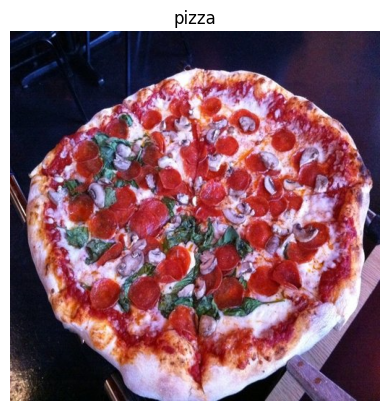

In [5]:
rand_image(targer_dir=r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train\\",
           target_class="pizza")

### Build End to End Model

Let's build a convolutional neural network to find patterns in our images, more specifically we need a way to:

- Load images
- Preprocessing images
- Build CNN to find patterns of images
- Compile our CNN
- Fit the CNN to training data

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set random seed
tf.random.set_seed(42)

# Preprocessing data (Scalling/Normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Data directiory
train_dir = r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train"
test_dir = r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\test"

# Import data from dir
train_data = train_datagen.flow_from_directory(directory=train_dir, batch_size=32, 
                                               target_size=(224,224), class_mode="binary",
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(directory=test_dir, batch_size=32, 
                                               target_size=(224,224), class_mode="binary",
                                               seed=42)

# # Build CNN model
# model_1 = tf.keras.Sequential([
#     tf.keras.layers.Conv2D(filters=10, kernel_size=3,
#                            activation="relu", input_shape=(224,224,3)),
#     tf.keras.layers.Conv2D(10, 3, activation="relu"),
#     tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),
#     tf.keras.layers.Conv2D(10, 3, activation="relu"),
#     tf.keras.layers.Conv2D(10, 3, activation="relu"),
#     tf.keras.layers.MaxPool2D(2),
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(1, activation="sigmoid")
# ])

# # Compile CNN Model
# model_1.compile(loss="binary_crossentropy",
#                 optimizer=tf.keras.optimizers.Adam(),
#                 metrics=["accuracy"])

# # Fit model
# history_1 = model_1.fit(train_data, epochs=5,
#                         steps_per_epoch=len(train_data),
#                         validation_data=valid_data,
#                         validation_steps= len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


#### Create Model 2 

Build new model with different specification as previous model. Our main key is make faster model

In [7]:
# # Random Set Seed
# tf.random.set_seed(42)

# model_2 = tf.keras.Sequential([
#     tf.keras.layers.Flatten(input_shape=(224,224,3)),
#     tf.keras.layers.Dense(4, activation="relu"),
#     tf.keras.layers.Dense(4, activation="relu"),
#     tf.keras.layers.Dense(1, activation="sigmoid")
# ])

# model_2.compile(loss="binary_crossentropy",
#             optimizer=tf.keras.optimizers.Adam(),
#             metrics=["accuracy"])

# history_2 = model_2.fit(train_data, epochs=5,
#                 steps_per_epoch=len(train_data),
#                 validation_data=valid_data,
#                 validation_steps=len(valid_data))

#### Create Model 3 to Improve Model 2

In [8]:
# # Random Set Seed
# tf.random.set_seed(42)

# # Create model
# model_3 = tf.keras.Sequential([
#     tf.keras.layers.Conv2D(filters=10, kernel_size=3,
#                            activation="relu", input_shape=(224,224,3)),
#     tf.keras.layers.Conv2D(10, 3, activation="relu"),
#     tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),
#     tf.keras.layers.MaxPool2D(2),
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(4, activation="relu"),
#     tf.keras.layers.Dense(4, activation="relu"),
#     tf.keras.layers.Dense(1, activation="sigmoid")
# ])

# model_3.compile(loss="binary_crossentropy",
#                 optimizer=tf.keras.optimizers.Adam(),
#                 metrics=["accuracy"])

# history_3 = model_3.fit(train_data, epochs=5,
#             steps_per_epoch=len(train_data),
#             validation_data=valid_data,
#             validation_steps=len(valid_data))

In [9]:
# model_3.summary()

#### Binary Classification Steps
1. Become one with the data.
2. Preprocess the data.
3. Created a model.
4. Fit the model.
5. Evaluate the model.
6. Adjust different parameters and improve the model.
8. Repeat until satisfied.

1. Become one with the data

['2410138.jpg']
Image shape: (512, 512, 3)
['1966967.jpg']
Image shape: (512, 512, 3)


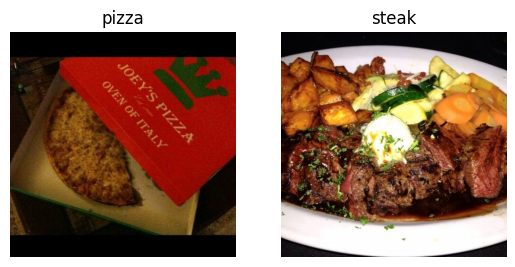

In [10]:
plt.figure()
plt.subplot(1,2,1)
pizza_image = rand_image(targer_dir=r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train\\",
           target_class="pizza")
plt.subplot(1,2,2)
steak_image = rand_image(targer_dir=r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train\\",
           target_class="steak")

2. Preprocessing the data

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen2 = ImageDataGenerator(rescale=1/255.)
test_datagen2 = ImageDataGenerator(rescale=1/255.)

In [12]:
train_data2 = train_datagen2.flow_from_directory(directory=train_dir,
                                                target_size=(224,224),
                                                class_mode="binary",
                                                batch_size=32)

test_data2 = test_datagen2.flow_from_directory(directory=test_dir,
                                               target_size=(224,224),
                                               class_mode="binary",
                                               batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [13]:
# Get images data sample
images, labels = next(train_data2)

In [14]:
images[:1].shape

(1, 224, 224, 3)

In [15]:
labels

array([1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1.,
       1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 0.],
      dtype=float32)

3. Create CNN model (start w/ a baseline)

In [16]:
# Necessary Dependencies

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import MaxPool2D, Conv2D, Dense, Flatten, Activation
from tensorflow.keras import Sequential

In [17]:
# Create model
model_4 = Sequential([
    Conv2D(filters=10,
           kernel_size=3,
           strides=1,
           padding="valid",
           activation="relu",
           input_shape=(224,224,3)),
    Conv2D(10, 3, activation="relu"),
    Conv2D(10, 3, activation="relu"),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# Compile model
model_4.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# Fit model w/ data
history_4 = model_4.fit(train_data2, epochs=5,
                        steps_per_epoch=len(train_data2),
                        validation_data=test_data2,
                        validation_steps=len(test_data2))



c:\Users\Diandra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Diandra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 36s 726ms/step - accuracy: 0.5949 - loss: 1.2222 - val_accuracy: 0.7600 - val_loss: 0.5193
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 315ms/step - accuracy: 0.7804 - loss: 0.4779 - val_accuracy: 0.8380 - val_loss: 0.3891
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 304ms/step - accuracy: 0.8534 - loss: 0.3681 - val_accuracy: 0.8580 - val_loss: 0.3353
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 323ms/step - accuracy: 0.8871 - loss: 0.2964 - val_accuracy: 0.8420 - val_loss: 0.3525
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 295ms/step - accuracy: 0.9468 - loss: 0.1869 - val_accuracy: 0.8560 - val_loss: 0.3258


In [18]:
import pandas as pd
# pd.DataFrame(history_4.history).plot()

In [19]:
def loss_curves_plot(history):
    
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    
    epochs = range(len(history.history["loss"]))
    
    # plot loss
    plt.plot(epochs, loss, label="Training loss")
    plt.plot(epochs, val_loss, label="Val loss")
    plt.title("Loss")
    plt.xlabel("epochs")
    plt.legend()
    
    # plot acc
    plt.figure()
    plt.plot(epochs, acc, label="Training accuracy")
    plt.plot(epochs, val_acc, label="Val accuracy")
    plt.title("Accuracy")
    plt.xlabel("epochs")
    plt.legend()

📝Note: When a model validation loss start to increase, it's likely that the model is overfitting the training dataset. This means, it's learning the patterns in the training dataset "too well" and thus the model ability to generalize to unseen data will be diminished.

In [20]:
# loss_curves_plot(history_4)

#### Adjust Model Parameters

Fitting a machine learning model comes in 3 steps:
1. Create a baseline
2. Beat the baseline by overfitting a larger model
3. Reduce overfitting

Ways to Induce overfitting:
1. Increase numbers of conv layers
2. Increase numbers of conv filters
3. Add another dense layer

Reduce overfitting:
1. Add data augmentation
2. Add regularization layers (such as MaxPool2D)
3. Add more data

📝: Reduce overfitting also known as reguralization

In [30]:
# Random set seed
tf.random.set_seed(42)

# Model
model_5 = Sequential([
    Conv2D(
        filters=10,
        kernel_size=3,
        strides=1,
        activation="relu",
        input_shape=(224,224,3)
    ),
    Conv2D(10, 3,activation="relu"),
    Conv2D(10, 3,activation="relu"),
    MaxPool2D(pool_size=2),
    MaxPool2D(),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# Compile model
model_5.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# Fit model
history_5 = model_5.fit(train_data2, epochs=5,
                        steps_per_epoch=len(train_data2),
                        validation_data=test_data2,
                        validation_steps=len(test_data2))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 218ms/step - accuracy: 0.5640 - loss: 0.6862 - val_accuracy: 0.7860 - val_loss: 0.5069
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 220ms/step - accuracy: 0.7944 - loss: 0.4686 - val_accuracy: 0.8480 - val_loss: 0.3822
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 221ms/step - accuracy: 0.8110 - loss: 0.4183 - val_accuracy: 0.8520 - val_loss: 0.3555
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 245ms/step - accuracy: 0.8234 - loss: 0.3873 - val_accuracy: 0.8700 - val_loss: 0.3206
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 257ms/step - accuracy: 0.8666 - loss: 0.3332 - val_accuracy: 0.8700 - val_loss: 0.3173


In [22]:
model_5.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 109, 109, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 27, 27, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7290)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         7,291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,175 (110.06 KB)

 Trainable params: 9,391 (36.68 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,784 (73.38 KB)

#### Finding Data Augmentation

In [23]:
# Create ImageDataGenerator training instance with data augmentation
train_datagen_augmented = ImageDataGenerator(horizontal_flip=True,
                                             height_shift_range=0.3,
                                             rescale=1/255.,
                                             rotation_range = 0.2,
                                             shear_range=0.2,
                                             zoom_range=0.2,
                                             width_shift_range=0.2)

# Create ImageDataGenerator training instance without data augmentation
train_datagen3 = ImageDataGenerator(rescale=1/255.)
test_datagen3 = ImageDataGenerator(rescale=1/255.)

In [123]:
# Image size
imgSize = (224,224)
batchSize = 32

# Create train augmented data batches
print("Augmented train data:")
train_data_augmented = train_datagen_augmented.flow_from_directory(directory=train_dir,
                                                                   batch_size=batchSize,
                                                                   class_mode="binary",
                                                                   target_size=imgSize,
                                                                   shuffle=True,)

# Crete train non augmented data batches
print("Non augmented train data:")
train_data3 = train_datagen3.flow_from_directory(directory=train_dir,
                                                 batch_size=batchSize,
                                                 class_mode="binary",
                                                 target_size=imgSize,
                                                 shuffle=False)

# Crete train non augmented data batches
print("Non augmented test data:")
test_data3 = test_datagen3.flow_from_directory(directory=test_dir,
                                               batch_size=batchSize,
                                               class_mode="binary",
                                               target_size=imgSize)

Augmented train data:
Found 1500 images belonging to 2 classes.
Non augmented train data:
Found 1500 images belonging to 2 classes.
Non augmented test data:
Found 500 images belonging to 2 classes.


Visualize non augmented & augmented images

In [132]:
images, labels = next(train_data3)
augmented_images, augmented_labels= next(train_data_augmented)
testImages3, testLabels3 = next(test_data3)

Showing image number:22


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

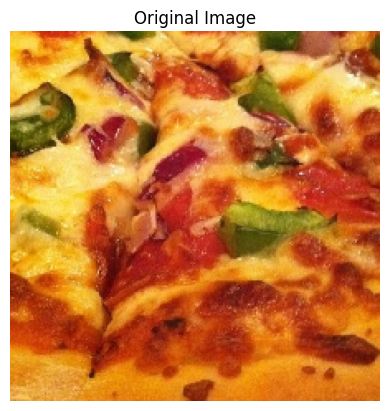

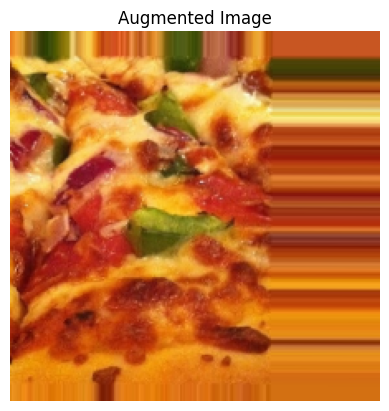

In [26]:
random_number = random.randint(0,32)
print(f"Showing image number:{random_number}")
plt.imshow(images[random_number])
plt.title(f"Original Image")
plt.axis(False)
plt.figure()
plt.imshow(augmented_images[random_number])
plt.title(f"Augmented Image")
plt.axis(False)

  

Images number: 21


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

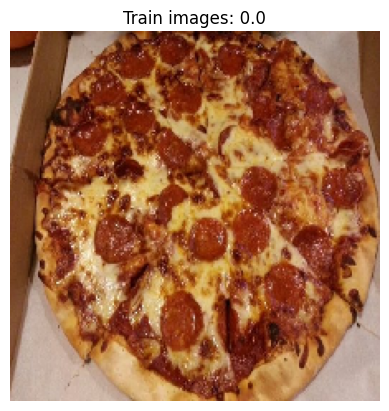

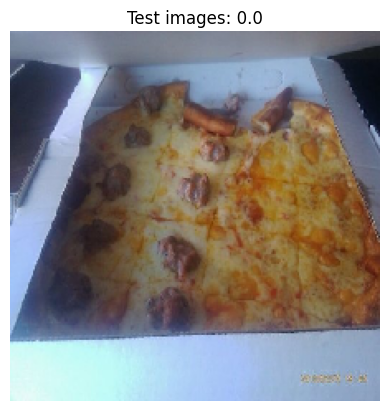

In [27]:
trainImages2, trainLabel2 = next(train_data2)
testImage2, testLabel2 = next(test_data2)

random_number2 = random.randint(0, 32)
print(f"Images number: {random_number2}")
plt.imshow(trainImages2[random_number])
plt.title(f"Train images: {trainLabel2[random_number]}")
plt.axis(False)
plt.figure()
plt.imshow(testImage2[random_number])
plt.title(f"Test images: {testLabel2[random_number]}")
plt.axis(False)


#### Create a new model with a augmented images as the train dataset

In [176]:
# Create model
model_6 = Sequential([
    Conv2D(input_shape=(224,224,3),
           filters=10,
           kernel_size=3,
           strides=1,
           activation="relu"),
    Conv2D(10,3, activation="relu"),
    Conv2D(10,3, activation="relu"),
    MaxPool2D(pool_size=2),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# Model compile
model_6.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# Model train
history_6 = model_6.fit(train_data_augmented,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=test_data2,
                        validation_steps=len(test_data3))


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.5607 - loss: 0.7855 - val_accuracy: 0.7300 - val_loss: 0.5275
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.7441 - loss: 0.5284 - val_accuracy: 0.7760 - val_loss: 0.4551
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 34s 713ms/step - accuracy: 0.7451 - loss: 0.5110 - val_accuracy: 0.8140 - val_loss: 0.4182
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 31s 649ms/step - accuracy: 0.7738 - loss: 0.4755 - val_accuracy: 0.8700 - val_loss: 0.3501
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 579ms/step - accuracy: 0.7940 - loss: 0.4485 - val_accuracy: 0.8600 - val_loss: 0.3493


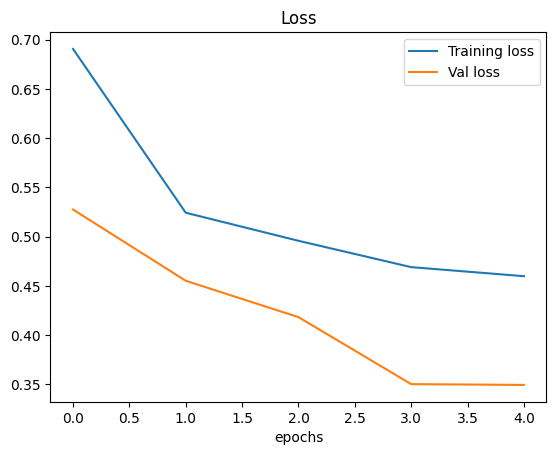

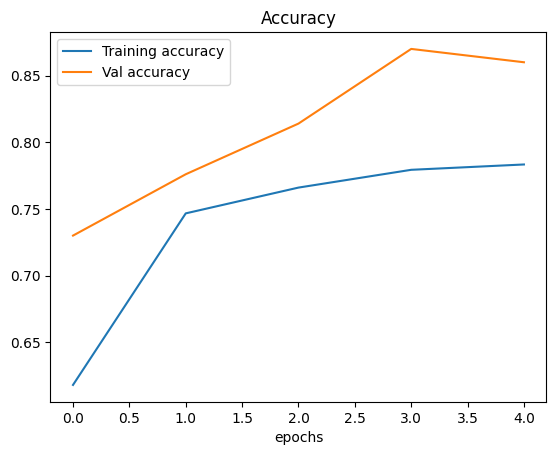

In [182]:
loss_curves_plot(history=history_6)

#### Testing Function

In [166]:
def pred_images(model, images, true_labels, classes):

    # Random image index
    i = random.randint(0, len(images))

    # Get image
    target_image = images[i]
    
    # Add batch dimension
    target_image_batches = tf.expand_dims(target_image, axis=0)

    # Predict
    pred_prob = model.predict(target_image_batches, verbose=0)[0][0]

    # Convert probability to class index
    pred_index = int(pred_prob > 0.5)

    # Get labels
    pred_label = classes[pred_index]
    # true_index = int(true_labels[i])
    true_labels = classes[int(true_labels[i])]

    # Color
    color = "green" if pred_label == true_labels else "red"

    # Plot Image
    print(i)
    plt.title("Train Image")
    plt.imshow(target_image)
    
    # Display
    plt.xlabel(
        "Pred: {} {:2.0f}% (True: {})".format(
            pred_label,
            pred_prob * 100 if pred_index == 1 else (1 - pred_prob) * 100,
            true_labels
        ),
        color=color
    )

26
steak


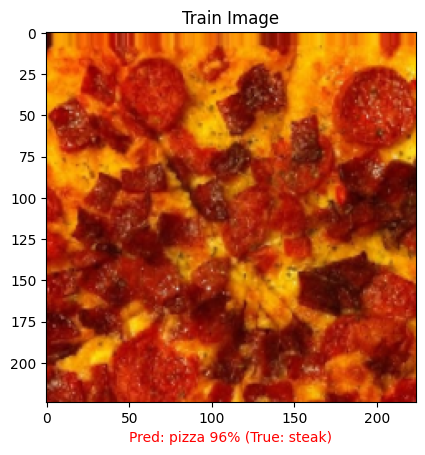

In [181]:
test_dir2 = pathlib.Path(r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\test")
class_names_test2 = np.array(sorted([item.name for item in test_dir2.glob("*")]))

pred_images(model=model_6, images=augmented_images, true_labels=testLabels3, classes=class_names)
# print(class_names_test2)